# Experiment 3: SMOTEENN + XGBoost

## 1. Scientific Motivation
Quasars and non-quasars exhibit high overlap in photometric colour space. While **oversampling** (SMOTE) generates minority data, and **undersampling** (Tomek Links) removes boundary noise, neither alone may be sufficient for highly overlapped distributions.

**SMOTEENN** is a powerful hybrid approach:
1. **SMOTE** generates synthetic quasar samples to balance the class distribution.
2. **ENN (Edited Nearest Neighbours)** aggressively cleans the resulting dataset by removing *any* instance (majority or minority) that is misclassified by its $k$ nearest neighbours.

This pipeline pairs aggressive data cleaning with **XGBoost**, a state-of-the-art non-linear ensemble learner. XGBoost excels at learning complex, non-linear boundaries but benefits greatly when noise and overlapping ambiguity are removed.


## 2. Research Question
Can a hybrid resampling strategy (SMOTEENN) paired with a gradient boosting ensemble (XGBoost) successfully disentangle highly overlapping photometric classes better than pure undersampling or pure oversampling?


## 3. Pipeline Philosophy
- **SMOTEENN**: generate minority samples, then aggressively remove noisy overlap from BOTH classes
- **XGBoost**: powerful gradient boosting tree algorithm capable of capturing complex non-linear feature interactions
- Together: **aggressive boundary cleaning + non-linear ensemble learning**


## 4. Setup & Data Loading


In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.combine import SMOTEENN

RANDOM_STATE = 42
TEST_SIZE = 0.2

data_path = '../../data/raw/Skyserver_Cross.csv'
df = pd.read_csv(data_path)
print(f'Dataset loaded. Full Shape: {df.shape}')


Dataset loaded. Full Shape: (500000, 7)


## 5. Binary Reformulation & Feature Engineering


In [2]:
df['target'] = (df['class'] == 'QSO').astype(int)

df['u_g'] = df['u'] - df['g']
df['g_r'] = df['g'] - df['r']
df['r_i'] = df['r'] - df['i']
df['i_z'] = df['i'] - df['z']

feature_cols = ['u', 'g', 'r', 'i', 'z', 'u_g', 'g_r', 'r_i', 'i_z']
X = df[feature_cols]
y = df['target']


## 6. Train-Test Split & Scaling


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 7. SMOTEENN Hybrid Resampling
Synthesise minority, then aggressively remove nearest-neighbour overlaps.


In [ ]:
print('Before SMOTEENN:', np.bincount(y_train))
smote_enn = SMOTEENN(sampling_strategy=0.5,random_state=RANDOM_STATE)
X_train_res, y_train_res = smote_enn.fit_resample(X_train_scaled, y_train)
print('After SMOTEENN:', np.bincount(y_train_res))


Before SMOTEENN: [339686  60314]
After SMOTEENN: [297862 325440]


## 8. Model Training


In [5]:
model = XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE)
model.fit(X_train_res, y_train_res)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


## 9. Evaluation


              precision    recall  f1-score   support

  Non-Quasar       0.99      0.91      0.95     84921
      Quasar       0.66      0.94      0.77     15079

    accuracy                           0.92    100000
   macro avg       0.82      0.93      0.86    100000
weighted avg       0.94      0.92      0.92    100000



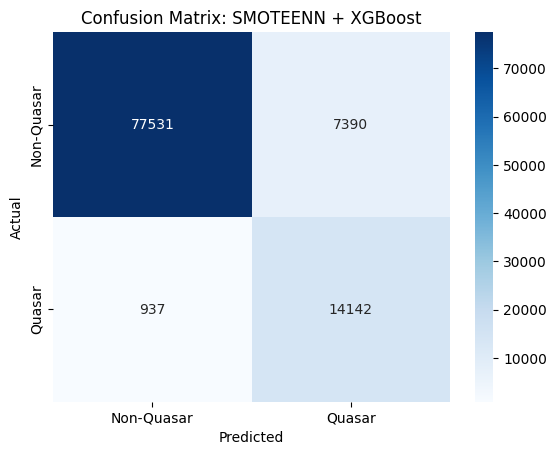

In [6]:
y_pred = model.predict(X_test_scaled)
print(classification_report(y_test, y_pred, target_names=['Non-Quasar', 'Quasar']))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Quasar', 'Quasar'], yticklabels=['Non-Quasar', 'Quasar'])
plt.title('Confusion Matrix: SMOTEENN + XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


## 10. Save Model for UI Deployment
Save the trained XGBoost model for Streamlit inference.


In [7]:
os.makedirs('../../models', exist_ok=True)
joblib.dump(model, '../../models/member3_xgboost.pkl')
joblib.dump(scaler, '../../models/scaler_m3.pkl')
print('Model and Scaler saved to models/ directory.')


Model and Scaler saved to models/ directory.


## 11. Theoretical Question
### How does hybrid resampling (SMOTEENN) affect the bias-variance tradeoff?

**What SMOTEENN does:**
1. **SMOTE** (Oversampling) creates synthetic minority examples. This *reduces bias* against the minority class, but can *increase variance* by introducing noisy synthetic samples into the majority class region.
2. **ENN** (Undersampling) removes any sample misclassified by its neighbours. This acts as a powerful noise filter, clearing the overlapping boundary. This *reduces variance* (by removing boundary ambiguity) and smooths the decision surface.

**The tradeoff:**
By combining both, SMOTEENN attempts to get the best of both worlds: enough minority samples to learn from (low bias), but with a clean, unambiguous boundary (low variance).
